In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import random
import tqdm
import os
from collections import deque

In [13]:
import os 
dir = os.getcwd()
leakdb = os.path.join(dir, "..")
text = os.path.join(leakdb, "txt")

In [27]:
import pandas as pd

def load_pipe_connections(pipes_path):
    
    df = pd.read_csv(pipes_path)
    cols = ["pipe_id", "node1", "node2"]
    
    df = df.drop(columns=[col for col in df.columns if col not in cols])
    
    start_nodes = df["node1"].astype(int).values
    end_nodes = df["node2"].astype(int).values
    pipe_ids = df["pipe_id"].astype(int).values
    
    start_nodes = torch.from_numpy(start_nodes).long()
    end_nodes   = torch.from_numpy(end_nodes).long()

    edge_index = torch.stack([start_nodes - 1, end_nodes - 1], dim=0)
    
    edge_meta = {
        "pipe_id": pipe_ids,
        "start_node": start_nodes,
        "end_node": end_nodes
    }
    
    print(f"Loaded {edge_index.shape[-1]} pipes.")
    return edge_index, edge_meta

In [15]:
pipes_path = r"C:\Users\Jash\OneDrive\Desktop\Research-Project\LeakDB\graph_1.csv"

In [16]:
def load_scenario_data(scenario_id, base_path=r"D:\LeakDB_full_data\Hanoi"):
    try:
        scenario_path = os.path.join(base_path, f"Scenario-{scenario_id}")
        if not os.path.exists(scenario_path):
            print(f"Scenario {scenario_id} not found.")
            return None
        
        leaks, timestamps = None, None
        demand_path = flow_path = pressure_path = None
        for sub in os.listdir(scenario_path):
            if sub in [f"Scenario-{scenario_id}", f"Scenario-{scenario_id}_info.csv", f"Hanoi_CMH_Scenario-{scenario_id}.inp"]:
                continue
            sub_path = os.path.join(scenario_path, sub)
            if sub == "Demands":
                demand_path = sub_path
            elif sub == "Flows":
                flow_path = sub_path
            elif sub == "Pressures":
                pressure_path = sub_path
            elif sub == "Labels.csv":
                leaks = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")
            elif sub == "Timestamps.csv":
                timestamps = pd.read_csv(sub_path).drop(columns=["Index"], errors="ignore")

        if not all([demand_path, flow_path, pressure_path, leaks is not None, timestamps is not None]):
            print(f"Scenario {scenario_id} is incomplete.")
            return None

        df = pd.concat([leaks, timestamps], axis=1, ignore_index=True)
        df.columns = ["Leaks", "Timestamps"]

        def combined_feature_df(path, feature):
            dfs = []
            for file in sorted(os.listdir(path)):
                file_path = os.path.join(path, file)
                if not file.endswith(".csv"):
                    continue
                sub_df = pd.read_csv(file_path).drop(columns="Index", errors="ignore")
                sub_df.columns = [f"{feature}_{file.split('.')[0]}"]
                dfs.append(sub_df)
            return pd.concat(dfs, axis=1, ignore_index=True)

        demand_df = combined_feature_df(demand_path, "demand")
        pressure_df = combined_feature_df(pressure_path, "pressure")
        flow_df = combined_feature_df(flow_path, "flow")

        demand_df.columns = [f"demand_node_{i}" for i in range(1, demand_df.shape[1] + 1)]
        pressure_df.columns = [f"pressure_node_{i}" for i in range(1, pressure_df.shape[1] + 1)]
        flow_df.columns = [f"flow_link_{i}" for i in range(1, flow_df.shape[1] + 1)]

        final_df = pd.concat([demand_df, pressure_df, flow_df, df], axis=1)
        final_df["Leaks"] = final_df["Leaks"].astype(int)
        return final_df

    except Exception as e:
        print(f"Error loading scenario {scenario_id}: {e}")
        return None

In [17]:
import random

SCENARIO_IDS = list(range(1, 21))
random.shuffle(SCENARIO_IDS)
  
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

WINDOW_SIZE = 5      
STEP = 1             
BATCH_SIZE = 512
LR = 1e-3
WEIGHT_DECAY = 1e-5
EPOCHS = 30
HIDDEN1 = 128
HIDDEN2 = 64
DROPOUT = 0.3
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [19]:
def aggregate_nonleak_rows(df, leak_col="Leaks"):
    data_cols = [c for c in df.columns if c != "Timestamps" and c != leak_col]
    out_rows = []
    i = 0
    n = len(df)
    while i < n:
        if df.iloc[i][leak_col] == 1:
            out_rows.append(df.iloc[i][data_cols + [leak_col]].to_dict())
            i += 1
            continue
        j = i
        while j < n and df.iloc[j][leak_col] == 0:
            j += 1
        run_len = j - i
        k = i
        while k + 3 <= j:
            window = df.iloc[k:k+3]
            avg_vals = window[data_cols].mean(axis=0).to_dict()
            avg_vals[leak_col] = 0
            out_rows.append(avg_vals)
            k += 3
        while k < j:
            out_rows.append(df.iloc[k][data_cols + [leak_col]].to_dict())
            k += 1
        i = j
    out_df = pd.DataFrame(out_rows)
    return out_df

In [20]:
class WindowedScenarioDataset(Dataset):
    def __init__(self, df_list, window_size=5, step=1):
        self.window_size = window_size
        self.step = step
        self.X = []
        self.y = []
        for df in df_list:
            arr = df.drop(columns=["Leaks"]).values.astype(np.float32)  
            labs = df["Leaks"].values.astype(np.int64)                
            T, F = arr.shape
            for start in range(0, T - window_size + 1, step):
                window = arr[start:start+window_size].reshape(-1)     
                target = labs[start + window_size - 1]            
                self.X.append(window)
                self.y.append(target)
        self.X = np.array(self.X, dtype=np.float32)
        self.y = np.array(self.y, dtype=np.int64)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [21]:
class LeakANN(nn.Module):
    def __init__(self, input_dim, hidden1=128, hidden2=64, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.bn1 = nn.BatchNorm1d(hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.bn2 = nn.BatchNorm1d(hidden2)
        self.fc3 = nn.Linear(hidden2, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = torch.sigmoid(x).squeeze(1)
        return x

In [22]:
def compute_global_mean_std(df_list):
    sum_ = None
    sumsq_ = None
    n_total = 0
    for df in df_list:
        arr = df.drop(columns=["Leaks"]).values.astype(np.float64)
        if sum_ is None:
            sum_ = arr.sum(axis=0)
            sumsq_ = (arr**2).sum(axis=0)
        else:
            sum_ += arr.sum(axis=0)
            sumsq_ += (arr**2).sum(axis=0)
        n_total += arr.shape[0]
    mean = sum_ / n_total
    var = (sumsq_ / n_total) - (mean**2)
    std = np.sqrt(np.maximum(var, 1e-6))
    return mean.astype(np.float32), std.astype(np.float32)

def normalize_df(df, mean, std):
    cols = [c for c in df.columns if c != "Leaks"]
    df2 = df.copy()
    df2[cols] = (df2[cols] - mean) / std
    return df2

In [29]:
def physics_informed_loss(bce_loss, pred, target, pressures, flows, demands, edge_index, lam=0.05):
    
    net_flow = flows.sum(dim=-1)
    total_demand = demands.sum(dim=-1)
    mass_balance_loss = torch.mean(torch.abs(net_flow - total_demand))
    loss = bce_loss + lam * mass_balance_loss
    return loss, bce_loss.item(), mass_balance_loss.item()

In [24]:
NUM_NODES = 32
NUM_PIPES = 34

DEMAND_IDX = slice(0, NUM_NODES)
PRESSURE_IDX = slice(NUM_NODES, (NUM_NODES + NUM_NODES))
FLOW_IDX = slice((2 * NUM_NODES), ((2 * NUM_NODES) + NUM_PIPES))

In [25]:
def main():
    
    edge_index, edge_meta = load_pipe_connections(pipes_path)
    
    all_dfs = []
    valid_ids = []
    missing = []
    print("Loading scenarios and applying aggregation...")
    for sid in tqdm.tqdm(SCENARIO_IDS):
        try:
            df = load_scenario_data(sid) 
            if df is None or len(df) == 0:
                missing.append(sid)
                continue
            if "Timestamps" in df.columns:
                df = df.drop(columns=["Timestamps"])
            if "Leaks" not in df.columns:
                raise ValueError(f"scenario {sid} missing 'Leaks' column")
            df_agg = aggregate_nonleak_rows(df, leak_col="Leaks")
            df_agg = df_agg.reset_index(drop=True)
            all_dfs.append(df_agg)
            valid_ids.append(sid)
        except Exception as e:
            print(f"Skipping scenario {sid}: {repr(e)}")
            missing.append(sid)
            continue
    print(f"Loaded {len(all_dfs)} scenarios; skipped {len(missing)} scenarios.")

    N = len(all_dfs)
    idxs = list(range(N))
    random.shuffle(idxs)
    n_train = int(N * TRAIN_RATIO)
    n_val = int(N * VAL_RATIO)
    train_idx = idxs[:n_train]
    val_idx = idxs[n_train:n_train + n_val]
    test_idx = idxs[n_train + n_val:]
    train_dfs = [all_dfs[i] for i in train_idx]
    val_dfs = [all_dfs[i] for i in val_idx]
    test_dfs = [all_dfs[i] for i in test_idx]
    print(f"Split: train={len(train_dfs)}, val={len(val_dfs)}, test={len(test_dfs)}")

    mean, std = compute_global_mean_std(train_dfs)
    
    np.savetxt(os.path.join(text, "mean_pinn_ann.txt"), mean)
    np.savetxt(os.path.join(text, "std_pinn_ann.txt"), std)
    
    train_dfs = [normalize_df(df, mean, std) for df in train_dfs]
    val_dfs = [normalize_df(df, mean, std) for df in val_dfs]
    test_dfs = [normalize_df(df, mean, std) for df in test_dfs]

    train_ds = WindowedScenarioDataset(train_dfs, window_size=WINDOW_SIZE, step=STEP)
    val_ds = WindowedScenarioDataset(val_dfs, window_size=WINDOW_SIZE, step=STEP)
    test_ds = WindowedScenarioDataset(test_dfs, window_size=WINDOW_SIZE, step=STEP)
    print("Dataset sizes (windows):", len(train_ds), len(val_ds), len(test_ds))

    input_dim = train_ds.X.shape[1] 
    unique, counts = np.unique(train_ds.y, return_counts=True)
    counts_map = dict(zip(unique, counts))
    n_pos = counts_map.get(1, 0)
    n_neg = counts_map.get(0, 0)
    print("Train class counts:", counts_map)
    weight_for_0 = 1.0 if n_neg == 0 else (n_pos + n_neg) / (2.0 * n_neg)
    weight_for_1 = 1.0 if n_pos == 0 else (n_pos + n_neg) / (2.0 * n_pos)
    pos_weight = torch.tensor(weight_for_1 / weight_for_0).to(DEVICE) 
    print(f"Class weights (approx): neg={weight_for_0:.3f}, pos={weight_for_1:.3f}")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
    
    model = LeakANN(input_dim, hidden1=HIDDEN1, hidden2=HIDDEN2, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
  
    def bce_weighted(preds, targets):
        eps = 1e-7
        preds = torch.clamp(preds, eps, 1 - eps)
        weights = torch.where(targets == 1, torch.tensor(weight_for_1, device=DEVICE), torch.tensor(weight_for_0, device=DEVICE))
        loss = - (weights * (targets.float() * torch.log(preds) + (1 - targets.float()) * torch.log(1 - preds)))
        return loss.mean()

    best_val_f1 = -1.0
    history = {"train_loss": [], "val_loss": [], "val_f1": []}

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            preds = model(xb)
            
            flow_batch = xb[:, FLOW_IDX]
            demand_batch = xb[:, DEMAND_IDX]
            pressure_batch = xb[:, PRESSURE_IDX] 
                      
            bce_loss = bce_weighted(preds, yb)
            
            loss, bce_val, physics_val = physics_informed_loss(bce_loss, preds, yb, pressure_batch, flow_batch, demand_batch, edge_index)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_ds)
        history["train_loss"].append(train_loss)
        
        if epoch % 5 == 0:
            print(f"Epoch {epoch} | BCE = {bce_val} | physics={physics_val}")

        model.eval()
        val_loss = 0.0
        preds_all = []
        labs_all = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                preds = model(xb)
                loss = bce_weighted(preds, yb)
                val_loss += loss.item() * xb.size(0)
                preds_all.append(preds.cpu().numpy())
                labs_all.append(yb.cpu().numpy())
        val_loss = val_loss / len(val_ds)
        preds_all = np.concatenate(preds_all)
        labs_all = np.concatenate(labs_all)
        pred_labels = (preds_all >= 0.5).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average='binary', zero_division=0)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(f1)

        print(f"Epoch {epoch}/{EPOCHS} - train_loss: {train_loss:.6f}  val_loss: {val_loss:.6f}  val_f1: {f1:.4f}")

        if f1 > best_val_f1:
            best_val_f1 = f1
            torch.save(model.state_dict(), os.path.join(leakdb, "best_leak_ann_pinn.pth"))
    print("Training finished. Best val F1:", best_val_f1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(history["val_f1"], label="val_f1")
    plt.xlabel("Epoch"); plt.ylabel("F1"); plt.legend()
    plt.title("Validation F1")
    plt.tight_layout()
    plt.savefig("training_curves.png")
    plt.show()

    model.load_state_dict(torch.load(os.path.join(leakdb, "best_leak_ann_pinn.pth")))
    model.eval()
    preds_all = []
    labs_all = []
    with torch.no_grad():
        for xb, yb in tqdm.tqdm(test_loader):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            preds = model(xb)
            preds_all.append(preds.cpu().numpy())
            labs_all.append(yb.cpu().numpy())
    preds_all = np.concatenate(preds_all)
    labs_all = np.concatenate(labs_all)
    pred_labels = (preds_all >= 0.5).astype(int)
    acc = accuracy_score(labs_all, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average='binary', zero_division=0)
    cm = confusion_matrix(labs_all, pred_labels)
    print("Test metrics: acc = {:.4f}, precision = {:.4f}, recall = {:.4f}, f1 = {:.4f}".format(acc, p, r, f1))
    print("Confusion matrix:\n", cm)

    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title("Confusion matrix (test)")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.savefig("confusion_matrix_test.png")
    plt.show()
    

In [32]:
model_path = os.path.join(leakdb, "best_leak_ann_pinn.pth")
mean = np.loadtxt(os.path.join(text, "mean_pinn_ann.txt"))
std = np.loadtxt(os.path.join(text, "std_pinn_ann.txt"))

Loaded 34 pipes.
Loading scenarios and applying aggregation...


100%|██████████| 20/20 [02:43<00:00,  8.16s/it]


Loaded 20 scenarios; skipped 0 scenarios.
Split: train=16, val=2, test=2
Dataset sizes (windows): 143058 22840 12482
Train class counts: {0: 68559, 1: 74499}
Class weights (approx): neg=1.043, pos=0.960
Epoch 1/30 - train_loss: 0.831562  val_loss: 0.423416  val_f1: 0.8251
Epoch 2/30 - train_loss: 0.760512  val_loss: 0.190862  val_f1: 0.9372
Epoch 3/30 - train_loss: 0.754237  val_loss: 0.266834  val_f1: 0.9093
Epoch 4/30 - train_loss: 0.747883  val_loss: 0.272754  val_f1: 0.9115
Epoch 5 | BCE = 0.017140609650970293 | physics=14.791732788085938
Epoch 5/30 - train_loss: 0.747750  val_loss: 0.263963  val_f1: 0.9160
Epoch 6/30 - train_loss: 0.745452  val_loss: 0.203547  val_f1: 0.9370
Epoch 7/30 - train_loss: 0.744919  val_loss: 0.229673  val_f1: 0.9299
Epoch 8/30 - train_loss: 0.744095  val_loss: 0.229687  val_f1: 0.9350
Epoch 9/30 - train_loss: 0.743574  val_loss: 0.170492  val_f1: 0.9491
Epoch 10 | BCE = 0.06513442883665735 | physics=15.143096923828125
Epoch 10/30 - train_loss: 0.742703 

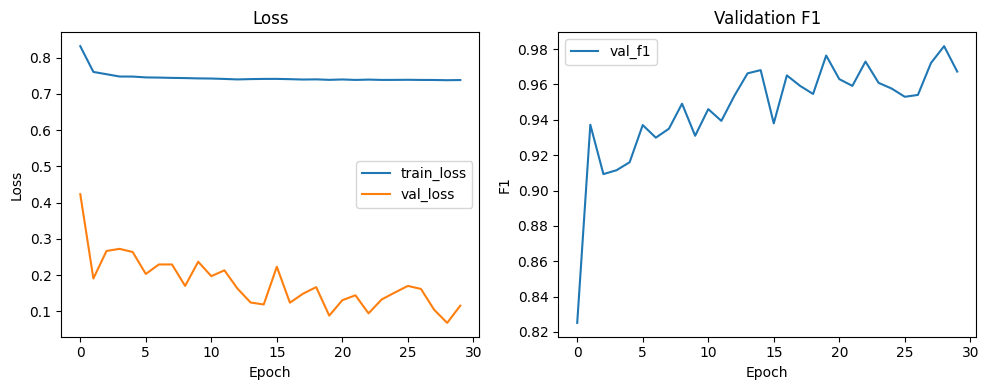

100%|██████████| 25/25 [00:00<00:00, 167.48it/s]


Test metrics: acc = 0.9530, precision = 0.7362, recall = 0.8025, f1 = 0.7679
Confusion matrix:
 [[10924   348]
 [  239   971]]


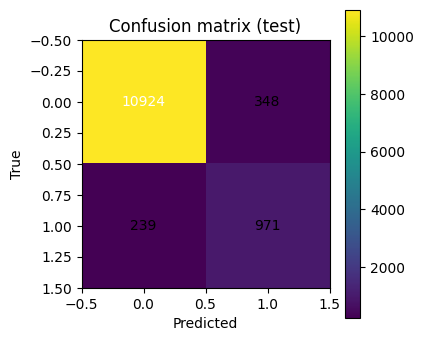

In [30]:
main()

In [31]:
def test_unseen_scenario(
   id,
   model_path = os.path.join(leakdb, "best_leak_ann.pth"),
   base_path = r"D:\LeakDB_full_data\Hanoi",
   mean=None,
   std=None,
   window_size=5,
   step=1,
   hidden1=128,
   hidden2=64,
   dropout=0.3,
   device=None 
):
    
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    df = load_scenario_data(id, base_path)
    
    if df is None:
        print(f"Scenario-{id} could not be loaded.")
        return None
    
    if "Timestamps" in df.columns:
        df = df.drop(columns=["Timestamps"])
        
    df = aggregate_nonleak_rows(df, leak_col="Leaks").reset_index(drop=True)
    
    if mean is None or std is None:
        raise ValueError("mean and std must be provided from training data.")
    
    df_norm = normalize_df(df, mean, std)
    
    unseen_ds = WindowedScenarioDataset([df_norm], window_size=window_size, step=step)
    unseen_loader = torch.utils.data.DataLoader(unseen_ds, batch_size=512, shuffle=False)
    
    input_dim = unseen_ds.X.shape[1]
    model = LeakANN(input_dim, hidden1=hidden1, hidden2=hidden2, dropout=dropout)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    
    preds_all, labs_all = [], []
    
    with torch.no_grad():
        for xb, yb in unseen_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb)
            preds_all.append(preds.cpu().numpy())
            labs_all.append(yb.cpu().numpy())
            
    preds_all = np.concatenate(preds_all)
    labs_all = np.concatenate(labs_all)
    pred_labels = (preds_all >= 0.5).astype(int)
    
    acc = accuracy_score(labs_all, pred_labels)
    p, r, f1, _ = precision_recall_fscore_support(labs_all, pred_labels, average="binary", zero_division=0)
    cm = confusion_matrix(labs_all, pred_labels)
    
    print(f"\nScenario {id} Results:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {p:.4f}")
    print(f"Recall:    {r:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("Confusion Matrix:\n", cm)
    
    plt.figure(figsize=(4, 4))
    plt.imshow(cm, interpolation="nearest", cmap="Blues")
    plt.title(f"Confusion Matrix - Scenario {id}")
    plt.colorbar()
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.show()
    
    return {
        "scenario_id": id,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "confusion_matrix": cm
    }


Scenario 22 Results:
Accuracy:  0.9905
Precision: 0.9997
Recall:    0.9798
F1 Score:  0.9897
Confusion Matrix:
 [[4534    1]
 [  79 3828]]


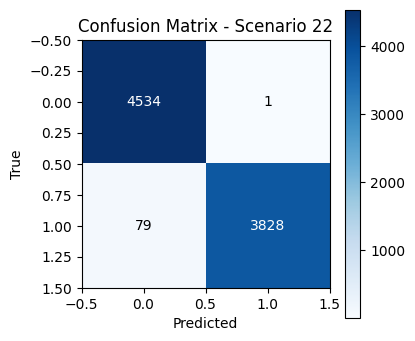

In [33]:
metrics = test_unseen_scenario(22, mean=mean, std=std)


Scenario 434 Results:
Accuracy:  0.6801
Precision: 0.9993
Recall:    0.3451
F1 Score:  0.5130
Confusion Matrix:
 [[4428    1]
 [2767 1458]]


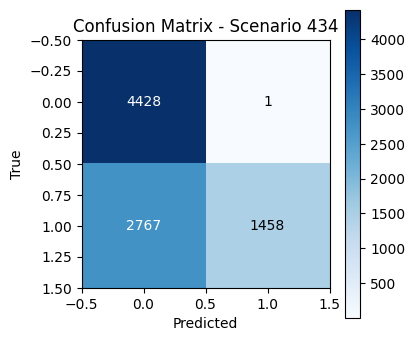

In [34]:
metrics = test_unseen_scenario(434, mean=mean, std=std)